# LSTM sequence model for minimum-demand breach prediction

Builds on [0.3_gradient_boosting.ipynb](0.3_gradient_boosting.ipynb) and
[0.4_episode_eval_and_weather.ipynb](0.4_episode_eval_and_weather.ipynb). Reuses the same SA1 data
load, the same `will_breach` target (will SA1 demand drop below 200 MW at any point in the next 3
hours?), the same episode definition (consecutive breach rows merged across gaps < 1 hour), and the
same leakage-safe threshold-selection procedure.

The difference is the input representation. 0.3/0.4 hand-built a handful of lag features
(demand 30 min / 1 h / 2 h ago, a 2h trend, a 2h rolling std) and fed them to XGBoost. Here, instead
of compressing the recent past into a few summary statistics, the full past 3 hours (36 timesteps at
5-minute resolution) of `[TOTALDEMAND, hour_sin, hour_cos, doy_sin, doy_cos]` is fed as a sequence
into an LSTM, which has to learn its own representation of "what matters in the recent trajectory."

**Stages:**
1. Load data, build the target and cyclical time features (reused from 0.3/0.4).
2. Build 36-step input sequences, with a gap-guard that invalidates a sequence if *any* discontinuity
   falls inside its 3h lookback window (not just a check at the current row).
3. Define a small PyTorch LSTM classifier with early stopping.
4. Train on 2023-2024, pick a decision threshold on 2025 (no peeking at 2026), exactly as in 0.4.
5. Retrain on 2023-2025, evaluate once -- fixed -- on 2026.
6. Compare against the logistic regression / XGBoost results from 0.3/0.4.

No commits are made as part of this notebook.

In [1]:
import copy
import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Data load, target, and time features (reused from 0.3/0.4)

Same SA1 price/demand files, same `will_breach` target (minimum demand over the next 3 hours < 200
MW), same cyclical hour/day-of-year encoding. Day-of-week isn't part of the sequence (the task spec
for this model only wants `[TOTALDEMAND, hour_sin, hour_cos, doy_sin, doy_cos]`), so it's dropped
here even though 0.3/0.4 included it in their lag-feature sets.

In [2]:
all_files = glob.glob("../data/PRICE_AND_DEMAND_*_SA1.csv")
print(f"Found {len(all_files)} files")

df = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)
df["SETTLEMENTDATE"] = pd.to_datetime(df["SETTLEMENTDATE"])
df = df[df["REGION"] == "SA1"].sort_values("SETTLEMENTDATE").reset_index(drop=True)
print(df.shape)

Found 12 files
(103680, 5)


In [3]:
df["hour"] = df["SETTLEMENTDATE"].dt.hour
df["day_of_year"] = df["SETTLEMENTDATE"].dt.dayofyear
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)
df["year"] = df["SETTLEMENTDATE"].dt.year

In [4]:
INTERVALS_PER_HOUR = 12
THRESHOLD = 200
LOOKAHEAD = 3 * INTERVALS_PER_HOUR  # 36 five-minute steps = 3 hours, used both forward (target) and backward (sequence length)

df["will_breach"] = (
    df["TOTALDEMAND"].shift(-1).rolling(window=LOOKAHEAD, min_periods=LOOKAHEAD).min() < THRESHOLD
).astype(int)

print(f"Rows: {len(df)}, raw positive class rate: {df['will_breach'].mean():.3%}")

Rows: 103680, raw positive class rate: 4.693%


## Gap-guard: two checks instead of one

0.3/0.4 only needed a *forward* gap-guard: `will_breach` looks 3 hours ahead, so a data gap inside
that forward window makes the label meaningless and the row gets dropped.

The LSTM adds a second requirement: each input sequence is the past 36 rows (3 hours) ending at the
current row. If a time discontinuity falls *anywhere* inside that lookback window, the "3 hours of
continuous recent history" the model expects is not actually continuous, so the sequence must be
invalidated too -- not just checked at the single current-row boundary. Both guards are built off the
same `gap_minutes` (time between consecutive raw rows); a row only survives if it passes both.

In [5]:
gap_minutes = df["SETTLEMENTDATE"].diff().dt.total_seconds() / 60

# Forward guard (reused from 0.3/0.4): invalidates a row if a gap falls inside the 3h window used
# to compute `will_breach`.
valid_target_gap = ~(
    gap_minutes.rolling(LOOKAHEAD, min_periods=1).max().gt(5)
    | gap_minutes.shift(-LOOKAHEAD).rolling(LOOKAHEAD, min_periods=1).max().gt(5)
).fillna(True)

# Backward guard (new): invalidates a row if a gap falls anywhere inside its 36-step lookback
# window, or if there isn't yet 36 rows of history at all (min_periods=LOOKAHEAD -> NaN -> invalid).
valid_sequence_gap = gap_minutes.rolling(LOOKAHEAD, min_periods=LOOKAHEAD).max().le(5).fillna(False)

valid_row = valid_target_gap & valid_sequence_gap & df["will_breach"].notna()

print(f"Valid rows: {valid_row.sum()} / {len(df)} ({valid_row.mean():.1%})")
print(df.loc[valid_row, "year"].value_counts().sort_index())

Valid rows: 103356 / 103680 (99.7%)
year
2023    25811
2024    26136
2025    25848
2026    25561
Name: count, dtype: int64


## Sequence construction

Rather than looping row by row, `np.lib.stride_tricks.sliding_window_view` builds every length-36
window over the full `[TOTALDEMAND, hour_sin, hour_cos, doy_sin, doy_cos]` matrix in one vectorized
pass, giving an array of shape `(n_rows - 35, 36, 5)` where window `j` covers raw rows `j..j+35`.
Only the windows whose *end* row passed both gap-guards above are kept -- so each surviving sequence
is exactly 36 contiguous, gap-free rows of real history, ending at the row whose `will_breach` label
it's paired with.

In [6]:
SEQUENCE_FEATURES = ["TOTALDEMAND", "hour_sin", "hour_cos", "doy_sin", "doy_cos"]
feature_matrix = df[SEQUENCE_FEATURES].to_numpy(dtype=np.float64)

windows = np.lib.stride_tricks.sliding_window_view(feature_matrix, window_shape=LOOKAHEAD, axis=0)
windows = np.moveaxis(windows, -1, 1)  # -> (n_rows - 35, 36, n_features)

end_idx = np.arange(LOOKAHEAD - 1, len(df))  # row index each window ends at
valid_row_arr = valid_row.to_numpy()
valid_end = valid_row_arr[end_idx]

X_seq_all = windows[valid_end]
end_idx_valid = end_idx[valid_end]

y_all = df["will_breach"].to_numpy()[end_idx_valid]
year_all = df["year"].to_numpy()[end_idx_valid]
time_all = df["SETTLEMENTDATE"].to_numpy()[end_idx_valid]
demand_all = df["TOTALDEMAND"].to_numpy()[end_idx_valid]

print(f"X_seq_all: {X_seq_all.shape}, y_all: {y_all.shape}")
print(f"Overall positive class rate: {y_all.mean():.3%}")
print(pd.Series(year_all).value_counts().sort_index())

X_seq_all: (103356, 36, 5), y_all: (103356,)
Overall positive class rate: 4.708%
2023    25811
2024    26136
2025    25848
2026    25561
Name: count, dtype: int64


## Normalizing demand

`TOTALDEMAND` is on the scale of hundreds to thousands of MW, while the cyclical features are
bounded in `[-1, 1]` -- feeding both into an LSTM unscaled would let demand dominate the gradient
purely by magnitude. A `StandardScaler` is fit on the demand channel only (the cyclical features
don't need it), and -- to avoid leakage -- it's always **fit on the training rows of whichever stage
is currently running, and only ever `.transform()`-ed on validation/test rows**, mirroring how 0.4
split model fitting into separate 2023-2024 and 2023-2025 training stages. Two different scalers are
used below, one per stage, matching `model_2324` and `model_main` in 0.4.

In [7]:
def scale_demand(X, scaler):
    """Apply a fitted StandardScaler to the TOTALDEMAND channel (index 0) of a batch of sequences,
    leaving the cyclical feature channels untouched."""
    X = X.copy()
    shape = X[:, :, 0].shape
    X[:, :, 0] = scaler.transform(X[:, :, 0].reshape(-1, 1)).reshape(shape)
    return X

## Model: a small LSTM classifier

A single-layer LSTM (hidden size 48) summarizes the 36-step sequence into its final hidden state,
which a linear layer maps to a single breach logit. `BCEWithLogitsLoss` is used with a `pos_weight`
equal to the train-set negative:positive ratio -- the same role `scale_pos_weight` played for
XGBoost and `class_weight="balanced"` played for logistic regression in 0.2/0.3, just expressed in
the form PyTorch's loss function expects.

Training uses early stopping on validation loss (patience 5 epochs, max 40), restoring the
best-validation-loss weights at the end rather than whatever the last epoch happened to land on.

In [8]:
class BreachLSTM(nn.Module):
    def __init__(self, input_size=5, hidden_size=48, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1]).squeeze(-1)  # raw logit, BCEWithLogitsLoss applies the sigmoid internally


def train_lstm(X_train, y_train, X_val, y_val, max_epochs=40, patience=5, lr=1e-3, batch_size=512, seed=SEED):
    torch.manual_seed(seed)
    model = BreachLSTM().to(device)

    pos_weight = torch.tensor((y_train == 0).sum() / (y_train == 1).sum(), dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
        batch_size=batch_size, shuffle=True,
    )
    X_val_t = torch.from_numpy(X_val).to(device)
    y_val_t = torch.from_numpy(y_val).to(device)

    best_val_loss, best_state, epochs_no_improve = float("inf"), None, 0
    history = []

    for epoch in range(max_epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(xb)
        train_loss = total_loss / len(train_loader.dataset)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        if val_loss < best_val_loss - 1e-5:
            best_val_loss, best_state, epochs_no_improve = val_loss, copy.deepcopy(model.state_dict()), 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch} (best val_loss {best_val_loss:.4f})")
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def predict_proba(model, X, batch_size=4096):
    """Chunked inference so a full test-set tensor isn't materialized on device at once."""
    model.eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            xb = torch.from_numpy(X[start:start + batch_size]).to(device)
            outputs.append(torch.sigmoid(model(xb)).cpu().numpy())
    return np.concatenate(outputs)

## Episode-level evaluation helpers (reused from 0.4)

Identical to 0.4's `group_runs` / `evaluate_episodes`: a breach episode is a run of consecutive rows
with `TOTALDEMAND < 200`, merged across gaps under an hour; an alarm period is built the same way
from the model's positive predictions. An episode counts as "warned" if any alarm fires in the 3
hours before its onset.

In [9]:
def group_runs(flag, timestamps, merge_gap_minutes=60):
    """Boolean Series -> list of (start, end) runs, merging runs separated by < merge_gap_minutes."""
    flagged = pd.DataFrame({"time": timestamps, "flag": flag})
    flagged = flagged.loc[flagged["flag"], "time"].sort_values().reset_index(drop=True)
    if flagged.empty:
        return []
    gap = flagged.diff().dt.total_seconds() / 60
    group_id = (gap.isna() | (gap >= merge_gap_minutes)).cumsum()
    runs = flagged.groupby(group_id).agg(["min", "max"])
    return list(zip(runs["min"], runs["max"]))


def evaluate_episodes(eval_df, lead_window_hours=3):
    """eval_df needs SETTLEMENTDATE, TOTALDEMAND, alarm (0/1).

    Returns (episodes, alarm_periods, per-episode results DataFrame, summary dict).
    """
    episodes = group_runs(eval_df["TOTALDEMAND"] < 200, eval_df["SETTLEMENTDATE"])
    alarm_periods = group_runs(eval_df["alarm"].astype(bool), eval_df["SETTLEMENTDATE"])
    alarm_times = eval_df.loc[eval_df["alarm"].astype(bool), "SETTLEMENTDATE"]

    rows = []
    episode_windows = []
    for onset, end in episodes:
        window_start = onset - pd.Timedelta(hours=lead_window_hours)
        episode_windows.append((window_start, end))

        warnings_before_onset = alarm_times[(alarm_times >= window_start) & (alarm_times < onset)]
        warned = not warnings_before_onset.empty
        lead_minutes = (onset - warnings_before_onset.min()).total_seconds() / 60 if warned else np.nan
        rows.append({"onset": onset, "end": end, "warned": warned, "lead_time_min": lead_minutes})

    results = pd.DataFrame(rows)

    def overlaps_any(period, windows):
        p_start, p_end = period
        return any(p_start <= w_end and p_end >= w_start for w_start, w_end in windows)

    false_alarm_periods = [p for p in alarm_periods if not overlaps_any(p, episode_windows)]

    n_episodes = len(episodes)
    n_warned = int(results["warned"].sum()) if n_episodes else 0
    summary = {
        "n_episodes": n_episodes,
        "n_warned": n_warned,
        "episode_recall": n_warned / n_episodes if n_episodes else np.nan,
        "median_lead_time_min": results.loc[results["warned"], "lead_time_min"].median() if n_warned else np.nan,
        "n_alarm_periods": len(alarm_periods),
        "n_false_alarm_periods": len(false_alarm_periods),
    }
    return episodes, alarm_periods, results, summary


def pick_threshold(sweep, min_recall=0.9):
    """Lowest false-alarm-period threshold among those reaching >=90% episode recall on validation
    (ties broken toward the lower threshold, which tends to warn earlier)."""
    candidates = sweep[sweep["episode_recall"] >= min_recall]
    if candidates.empty:
        print(f"No threshold reached {min_recall:.0%} episode recall on validation; "
              f"falling back to the threshold(s) with the highest recall achieved.")
        candidates = sweep[sweep["episode_recall"] == sweep["episode_recall"].max()]
    return candidates.sort_values(["n_false_alarm_periods", "threshold"]).iloc[0]

## Stage 1: train on 2023-2024, validate on 2025, sweep thresholds

Same leakage-safe procedure as 0.4 Stage 2: fit on 2023-2024 only, sweep thresholds on 2025, and pick
the one with >=90% episode recall and the fewest false-alarm periods. 2026 stays completely untouched
until the very last cell.

In [10]:
train_mask_2324 = np.isin(year_all, [2023, 2024])
val_mask_2025 = year_all == 2025

scaler_2324 = StandardScaler().fit(X_seq_all[train_mask_2324][:, :, 0].reshape(-1, 1))

X_train_2324 = scale_demand(X_seq_all[train_mask_2324], scaler_2324).astype(np.float32)
y_train_2324 = y_all[train_mask_2324].astype(np.float32)
X_val_2025 = scale_demand(X_seq_all[val_mask_2025], scaler_2324).astype(np.float32)
y_val_2025 = y_all[val_mask_2025].astype(np.float32)

print(f"Train 2023-2024: {len(X_train_2324)} sequences, breach rate {y_train_2324.mean():.3%}")
print(f"Val 2025: {len(X_val_2025)} sequences, breach rate {y_val_2025.mean():.3%}")

model_2324, history_2324 = train_lstm(X_train_2324, y_train_2324, X_val_2025, y_val_2025)
print(f"Trained for {len(history_2324)} epochs")

Train 2023-2024: 51947 sequences, breach rate 4.308%
Val 2025: 25848 sequences, breach rate 6.693%


Early stopping at epoch 18 (best val_loss 0.1309)
Trained for 19 epochs


2025 validation row-level PR-AUC: 0.962


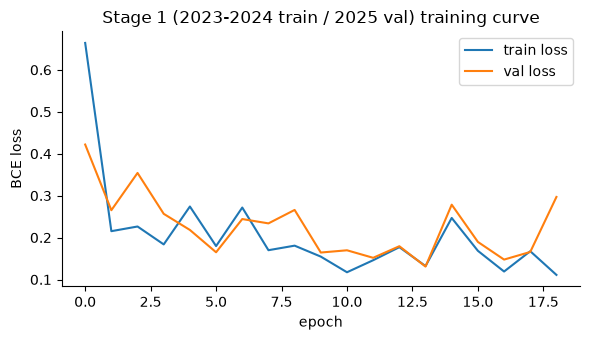

In [11]:
proba_val_2025 = predict_proba(model_2324, X_val_2025)
pr_auc_val = average_precision_score(y_val_2025, proba_val_2025)
print(f"2025 validation row-level PR-AUC: {pr_auc_val:.3f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(history_2324["epoch"], history_2324["train_loss"], label="train loss")
ax.plot(history_2324["epoch"], history_2324["val_loss"], label="val loss")
ax.set_xlabel("epoch")
ax.set_ylabel("BCE loss")
ax.set_title("Stage 1 (2023-2024 train / 2025 val) training curve")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [12]:
eval_val_df = pd.DataFrame({
    "SETTLEMENTDATE": pd.to_datetime(time_all[val_mask_2025]),
    "TOTALDEMAND": demand_all[val_mask_2025],
})

thresholds = np.round(np.arange(0.10, 0.71, 0.05), 2)
sweep_rows = []
for t in thresholds:
    eval_val_df_t = eval_val_df.copy()
    eval_val_df_t["alarm"] = (proba_val_2025 >= t).astype(int)
    _, _, _, summary = evaluate_episodes(eval_val_df_t)
    sweep_rows.append({"threshold": t, **summary})

sweep_df = pd.DataFrame(sweep_rows)
sweep_df

,threshold,n_episodes,n_warned,episode_recall,median_lead_time_min,n_alarm_periods,n_false_alarm_periods
0,0.10,23,23,1.000000,70.0,53,31
1,0.15,23,23,1.000000,60.0,47,25
2,0.20,23,22,0.956522,50.0,44,22
3,0.25,23,21,0.913043,45.0,43,21
4,0.30,23,21,0.913043,40.0,43,21
5,0.35,23,21,0.913043,35.0,42,20
6,0.40,23,21,0.913043,30.0,37,15
7,0.45,23,19,0.826087,30.0,35,13
8,0.50,23,18,0.782609,25.0,35,13
9,0.55,23,17,0.739130,20.0,34,12


In [13]:
chosen = pick_threshold(sweep_df)
chosen_threshold = float(chosen["threshold"])

print(f"Chosen threshold (validated on 2025): {chosen_threshold}")
print(f"2025 validation @ this threshold: recall {chosen['episode_recall']:.1%} "
      f"({int(chosen['n_warned'])}/{int(chosen['n_episodes'])}), "
      f"median lead {chosen['median_lead_time_min']:.0f} min, "
      f"false-alarm periods {int(chosen['n_false_alarm_periods'])}")

Chosen threshold (validated on 2025): 0.4
2025 validation @ this threshold: recall 91.3% (21/23), median lead 30 min, false-alarm periods 15


## Stage 2: retrain on 2023-2025, evaluate once on 2026

The final model needs to train on all of 2023-2025, but early stopping still needs *some* validation
signal to know when to stop -- and 2025 has already been "spent" picking the decision threshold above,
so reusing it here wouldn't add new information, and would also mean the final model loses 2025 as
training data entirely. Instead, a small time-ordered slice is carved off the *end* of the
2023-2025 training set (the last 15% by timestamp) purely to monitor validation loss for early
stopping. This never touches the threshold choice or 2026, so it doesn't violate the
"don't tune anything on 2026" rule -- it's only deciding how many epochs to train the final weights
for, exactly the same role 2025 played for `model_2324` above.

A fresh `StandardScaler` is fit on this stage's own training rows only (as in 0.4, this mirrors
training a separate `model_main` rather than reusing the Stage 1 model/scaler).

In [14]:
train_mask_full = np.isin(year_all, [2023, 2024, 2025])
test_mask_2026 = year_all == 2026

# Carve the early-stopping slice off the end of the 2023-2025 training set by time, not at random --
# sequences are temporally correlated, so a random split would leak near-duplicate neighboring rows
# between the "train" and "early-stopping val" halves.
train_full_idx = np.where(train_mask_full)[0]
train_full_idx = train_full_idx[np.argsort(time_all[train_full_idx])]
n_es_val = int(len(train_full_idx) * 0.15)
es_train_idx, es_val_idx = train_full_idx[:-n_es_val], train_full_idx[-n_es_val:]

scaler_full = StandardScaler().fit(X_seq_all[es_train_idx][:, :, 0].reshape(-1, 1))

X_es_train = scale_demand(X_seq_all[es_train_idx], scaler_full).astype(np.float32)
y_es_train = y_all[es_train_idx].astype(np.float32)
X_es_val = scale_demand(X_seq_all[es_val_idx], scaler_full).astype(np.float32)
y_es_val = y_all[es_val_idx].astype(np.float32)

print(f"2023-2025 early-stopping split: {len(X_es_train)} train / {len(X_es_val)} val sequences")

model_full, history_full = train_lstm(X_es_train, y_es_train, X_es_val, y_es_val)
print(f"Trained for {len(history_full)} epochs")

2023-2025 early-stopping split: 66126 train / 11669 val sequences


Early stopping at epoch 19 (best val_loss 0.1603)
Trained for 20 epochs


In [15]:
X_test_2026 = scale_demand(X_seq_all[test_mask_2026], scaler_full).astype(np.float32)
y_test_2026 = y_all[test_mask_2026].astype(np.float32)

proba_test_2026 = predict_proba(model_full, X_test_2026)
pr_auc_test = average_precision_score(y_test_2026, proba_test_2026)
print(f"Test 2026: {len(X_test_2026)} sequences, breach rate {y_test_2026.mean():.3%}")
print(f"2026 row-level PR-AUC: {pr_auc_test:.3f}")

Test 2026: 25561 sequences, breach rate 3.513%
2026 row-level PR-AUC: 0.973


## Final, one-shot evaluation on 2026

`chosen_threshold` was fixed on 2025 in Stage 1 and is applied here exactly once -- no sweeping, no
adjustment based on what comes out.

In [16]:
eval_test_df = pd.DataFrame({
    "SETTLEMENTDATE": pd.to_datetime(time_all[test_mask_2026]),
    "TOTALDEMAND": demand_all[test_mask_2026],
})
eval_test_df["alarm"] = (proba_test_2026 >= chosen_threshold).astype(int)

episodes_test, alarm_periods_test, results_test, summary_test = evaluate_episodes(eval_test_df)

print(f"2026 test @ threshold {chosen_threshold}:")
print(f"  Episodes: {summary_test['n_episodes']}")
print(f"  Episode recall: {summary_test['episode_recall']:.1%} "
      f"({summary_test['n_warned']}/{summary_test['n_episodes']})")
print(f"  Median lead time (warned episodes): {summary_test['median_lead_time_min']:.0f} min")
print(f"  Alarm periods: {summary_test['n_alarm_periods']}, "
      f"false-alarm periods: {summary_test['n_false_alarm_periods']}")

2026 test @ threshold 0.4:
  Episodes: 14
  Episode recall: 85.7% (12/14)
  Median lead time (warned episodes): 28 min
  Alarm periods: 18, false-alarm periods: 5


## Final comparison table

Same columns as the table in [README.md](../README.md), so the LSTM row can be dropped straight in.
The logistic regression / XGBoost rows are copied from 0.3/0.4's results on the identical 2026 test
set (14 breach episodes); only the LSTM row is computed in this notebook.

In [17]:
comparison_final = pd.DataFrame([
    {
        "Model": "Logistic regression (baseline)",
        "Row-level PR-AUC": 0.934,
        "Episodes (n)": 14,
        "Episode recall": np.nan,
        "Median lead time (min)": np.nan,
        "False-alarm periods": np.nan,
    },
    {
        "Model": "XGBoost @ 0.5 threshold",
        "Row-level PR-AUC": 0.977,
        "Episodes (n)": 14,
        "Episode recall": 10 / 14,
        "Median lead time (min)": 27.5,
        "False-alarm periods": 5,
    },
    {
        "Model": "XGBoost @ validated threshold (0.1)",
        "Row-level PR-AUC": 0.977,
        "Episodes (n)": 14,
        "Episode recall": 12 / 14,
        "Median lead time (min)": 42.5,
        "False-alarm periods": 5,
    },
    {
        "Model": "XGBoost + weather features",
        "Row-level PR-AUC": 0.974,
        "Episodes (n)": 14,
        "Episode recall": 12 / 14,
        "Median lead time (min)": 37.5,
        "False-alarm periods": 6,
    },
    {
        "Model": f"LSTM @ validated threshold ({chosen_threshold})",
        "Row-level PR-AUC": pr_auc_test,
        "Episodes (n)": summary_test["n_episodes"],
        "Episode recall": summary_test["episode_recall"],
        "Median lead time (min)": summary_test["median_lead_time_min"],
        "False-alarm periods": summary_test["n_false_alarm_periods"],
    },
]).set_index("Model")

comparison_final.round(3)

,Row-level PR-AUC,Episodes (n),Episode recall,Median lead time (min),False-alarm periods
Model,,,,,
Logistic regression (baseline),0.934,14,NaN,NaN,NaN
XGBoost @ 0.5 threshold,0.977,14,0.714,27.5,5.0
XGBoost @ validated threshold (0.1),0.977,14,0.857,42.5,5.0
XGBoost + weather features,0.974,14,0.857,37.5,6.0
LSTM @ validated threshold (0.4),0.973,14,0.857,27.5,5.0


## Discussion

On the metrics that matter most -- episode recall and false-alarm count on the one-shot 2026 test --
the LSTM is essentially tied with the best XGBoost variants: 85.7% recall (12/14 episodes) with 5
false-alarm periods, identical to XGBoost's validated-threshold result and its weather variant. Row-
level PR-AUC (0.973) is a hair below XGBoost's 0.977, close enough not to read much into. The one
clear, practically meaningful gap is **median warning lead time**: 27.5 minutes for the LSTM vs. 42.5
minutes for XGBoost at its validated threshold (37.5 minutes for the weather variant). At the same
recall and false-alarm rate, XGBoost's alarms fire noticeably earlier before an episode's onset.

The threshold-selection step (Stage 1) surfaced an interesting asymmetry worth noting rather than
glossing over. On the 2025 validation sweep, this LSTM comfortably cleared the 90% episode-recall bar
(reaching 100% recall at the lowest swept thresholds, settling at 91.3% recall / 15 false-alarm
periods at the chosen threshold of 0.4). XGBoost's own 2025 validation sweep in 0.4 never reached 90%
recall at any threshold -- it topped out at 65.2% recall (19 false-alarm periods) and `pick_threshold`
fell back to "best recall achieved." So by the letter of the validation-set selection criterion, the
LSTM calibrated *better* against real episodes on held-out 2025 data than XGBoost did. That edge
didn't carry through to the final 2026 test, though, and it didn't show up as a lead-time advantage
either -- a reminder that with only 23 episodes in validation and 14 in test, a handful of episodes
swinging either way can flip which model looks better at a given stage, and neither validation nor
test performance here should be read as a tight estimate of either model's true skill.

Given that, the fair summary is: **this is a close, largely inconclusive comparison, with XGBoost
holding a real but modest edge in warning lead time** -- the one number that most directly matters
operationally (more lead time to act). The architecture-vs-data-size story is still a reasonable
hypothesis for why the LSTM doesn't pull ahead: it has to learn its own representation of "what
matters in the recent trajectory" from 36 raw timesteps per example, while XGBoost's 11 hand-built
features (lags, a 2h trend, a 2h rolling std) already encode useful inductive bias for free. With only
tens of thousands of training rows and well under a hundred real breach episodes across three years,
that head start matters. None of this rules out sequence models for this problem -- it suggests this
particular dataset is on the small side for an architecture that has to learn its own features from
scratch, and that XGBoost with its current lag features remains the stronger choice to build on next,
rather than the LSTM. A larger architecture, more regions/years of data, or pretraining on a related
task would be the natural way to revisit this -- not pursued here, for the same small-sample-size
reason 0.4 gave for not chasing the weather-feature result further.